<a href="https://colab.research.google.com/github/0neAnd0nlyKen/steam-games-sentiment-analysis/blob/main/Steam_Games_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load Dataset**

In [44]:

!git clone -b apdd-kelompok-5 https://github.com/0neAnd0nlyKen/steam-games-sentiment-analysis.git

Cloning into 'steam-games-sentiment-analysis'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 76 (delta 20), reused 52 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 5.24 MiB | 14.55 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [2]:
%cd /content/steam-games-sentiment-analysis/
!ls

/content/apdd_kelompok-5
fp.ipynb  steamdb-sentiment.csv  tokopedia-test1.csv  tokopedia-test.csv


In [3]:
import pandas as pd
df = pd.read_csv('steamdb-sentiment.csv')

In [4]:
df.head()

,web-scraper-order,web-scraper-start-url,game,game-href,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Month,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
0,1751940014-1,https://steamdb.info/charts/?sort=peak,Sultan's Game,https://steamdb.info/app/3117820/charts/,"55,412",117,"13,662",~491.3 k,~719.2 k,~1.01 M,June 2025,"16,432","-5,100",-23.70%,"5,242",-36.30%,😍 92.50%
1,1751940020-2,https://steamdb.info/charts/?sort=peak,HoloCure - Save the Fans!,https://steamdb.info/app/2420510/charts/,"34,146",52,"26,519",~917.3 k,~1.15 M,~1.89 M,June 2025,"1,123",-173,-13.30%,694,-14.00%,🤩 96.99%
2,1751940026-3,https://steamdb.info/charts/?sort=peak,Like a Dragon: Infinite Wealth,https://steamdb.info/app/2072450/charts/,"48,734",324,"76,294",~500.1 k,~600.0 k,~605.2 k,June 2025,"1,720",-458,-21.00%,760,-27.10%,😎 89.46%
3,1751940031-4,https://steamdb.info/charts/?sort=peak,Call of Duty®: Modern Warfare® 3 (2011),https://steamdb.info/app/42680/charts/,"74,209",~3.61 M,~4.09 M,"74,209",259,412,June 2025,536,+70,+15.0%,286,+16.7%,NaN
4,1751940037-5,https://steamdb.info/charts/?sort=peak,Core Keeper,https://steamdb.info/app/1621690/charts/,"156,996","1,172","54,513",~1.69 M,~2.98 M,~3.42 M,June 2025,"8,223",+305,+3.9%,"3,549",-10.30%,😍 91.26%


In [5]:
df.columns

Index(['web-scraper-order', 'web-scraper-start-url', 'game', 'game-href',
       'followers', 'twitch-viewers-24-hours', 'twitch-viewers-all-time',
       'owner-estimations-vg', 'owner-estimations-SteamSpy',
       'owner-estimations-PlayTracker', 'Month', 'Peak', 'Gain', 'Gain-pct',
       'Average', 'Avg-Gain-pct', 'user-reviews'],
      dtype='object')

In [6]:
df = df.drop(['web-scraper-order', 'web-scraper-start-url', 'game', 'game-href','Month'], axis=1)

In [7]:
df.head()

,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
0,"55,412",117,"13,662",~491.3 k,~719.2 k,~1.01 M,"16,432","-5,100",-23.70%,"5,242",-36.30%,😍 92.50%
1,"34,146",52,"26,519",~917.3 k,~1.15 M,~1.89 M,"1,123",-173,-13.30%,694,-14.00%,🤩 96.99%
2,"48,734",324,"76,294",~500.1 k,~600.0 k,~605.2 k,"1,720",-458,-21.00%,760,-27.10%,😎 89.46%
3,"74,209",~3.61 M,~4.09 M,"74,209",259,412,536,+70,+15.0%,286,+16.7%,NaN
4,"156,996","1,172","54,513",~1.69 M,~2.98 M,~3.42 M,"8,223",+305,+3.9%,"3,549",-10.30%,😍 91.26%


In [8]:
df.columns

Index(['followers', 'twitch-viewers-24-hours', 'twitch-viewers-all-time',
       'owner-estimations-vg', 'owner-estimations-SteamSpy',
       'owner-estimations-PlayTracker', 'Peak', 'Gain', 'Gain-pct', 'Average',
       'Avg-Gain-pct', 'user-reviews'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   followers                      111 non-null    object
 1   twitch-viewers-24-hours        105 non-null    object
 2   twitch-viewers-all-time        103 non-null    object
 3   owner-estimations-vg           104 non-null    object
 4   owner-estimations-SteamSpy     104 non-null    object
 5   owner-estimations-PlayTracker  99 non-null     object
 6   Peak                           116 non-null    object
 7   Gain                           116 non-null    object
 8   Gain-pct                       116 non-null    object
 9   Average                        116 non-null    object
 10  Avg-Gain-pct                   116 non-null    object
 11  user-reviews                   101 non-null    object
dtypes: object(12)
memory usage: 11.1+ KB


In [10]:
df = df.dropna(subset=['Peak', 'Gain', 'Gain-pct', 'Average', 'Avg-Gain-pct'], how='all')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   followers                      110 non-null    object
 1   twitch-viewers-24-hours        104 non-null    object
 2   twitch-viewers-all-time        103 non-null    object
 3   owner-estimations-vg           104 non-null    object
 4   owner-estimations-SteamSpy     104 non-null    object
 5   owner-estimations-PlayTracker  99 non-null     object
 6   Peak                           116 non-null    object
 7   Gain                           116 non-null    object
 8   Gain-pct                       116 non-null    object
 9   Average                        116 non-null    object
 10  Avg-Gain-pct                   116 non-null    object
 11  user-reviews                   101 non-null    object
dtypes: object(12)
memory usage: 11.8+ KB


In [12]:
import re

df_int = df.copy()

def parse_number(s):
    if not isinstance(s, str):
        return None
    s = s.replace(',', '').replace(' ', '')

    # Modified regex to handle negative numbers
    match = re.findall(r'(-?[\d.]+)([kKmM]?)', s)

    if match:
        num, suffix = match[0]
        try:
            n = float(num)
            if suffix.lower() == 'k':
                n *= 1_000
            elif suffix.lower() == 'm':
                n *= 1_000_000
            return int(n)
        except:
            return None
    return None

# Apply to all string columns and overwrite with parsed int values
for col in df_int.select_dtypes(include='object').columns:
    df_int[col] = df_int[col].apply(parse_number)

df_int.head()

,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
0,55412.0,117.0,13662.0,491300.0,719200.0,1010000.0,16432,-5100.0,-23.0,5242.0,-36.0,92.0
1,34146.0,52.0,26519.0,917300.0,1150000.0,1890000.0,1123,-173.0,-13.0,694.0,-14.0,96.0
2,48734.0,324.0,76294.0,500100.0,600000.0,605200.0,1720,-458.0,-21.0,760.0,-27.0,89.0
3,74209.0,3610000.0,4090000.0,74209.0,259.0,412.0,536,70.0,15.0,286.0,16.0,NaN
4,156996.0,1172.0,54513.0,1690000.0,2980000.0,3420000.0,8223,305.0,3.0,3549.0,-10.0,91.0


In [13]:
df_int.isnull().sum()

,0
followers,6
twitch-viewers-24-hours,12
twitch-viewers-all-time,13
owner-estimations-vg,12
owner-estimations-SteamSpy,12
owner-estimations-PlayTracker,17
Peak,0
Gain,4
Gain-pct,4
Average,1


In [14]:
df_filled = df_int.copy()

In [15]:
df_filled.dropna(subset=['user-reviews'], how='all', inplace=True)
df_filled.isnull().sum()

,0
followers,0
twitch-viewers-24-hours,1
twitch-viewers-all-time,1
owner-estimations-vg,2
owner-estimations-SteamSpy,2
owner-estimations-PlayTracker,6
Peak,0
Gain,2
Gain-pct,2
Average,0


In [16]:
df_filled[df_filled.isnull().any(axis=1)]

,followers,twitch-viewers-24-hours,twitch-viewers-all-time,owner-estimations-vg,owner-estimations-SteamSpy,owner-estimations-PlayTracker,Peak,Gain,Gain-pct,Average,Avg-Gain-pct,user-reviews
38,1793.0,0.0,14.0,1610000.0,1700000.0,NaN,34,-2.0,-5.0,1.0,-50.0,65.0
46,56058.0,5430000.0,7230000.0,NaN,NaN,NaN,75858,-11555.0,-13.0,43674.0,-3.0,68.0
47,247114.0,10335.0,221716.0,1260000.0,1400000.0,1490000.0,189333,NaN,NaN,96218.0,NaN,77.0
51,171097.0,2514.0,97724.0,1250000.0,1830000.0,1900000.0,192078,NaN,NaN,62777.0,NaN,91.0
53,234702.0,1.0,37.0,810200.0,3140000.0,NaN,192501,-2007.0,-1.0,151410.0,7.0,95.0
59,8746.0,0.0,7610.0,2380000.0,3950000.0,NaN,48,3.0,6.0,11.0,-15.0,79.0
61,4396.0,0.0,491.0,1980000.0,5130000.0,NaN,32,-4.0,-11.0,2.0,0.0,78.0
104,11883.0,NaN,NaN,NaN,NaN,NaN,6329,-12468.0,-66.0,915.0,-64.0,93.0


In [17]:
cols_to_drop_na = ['Peak', 'Gain', 'Gain-pct', 'Average', 'Avg-Gain-pct']
df_filled.dropna(subset=cols_to_drop_na, inplace=True)

cols_to_fill_mean = ['followers', 'twitch-viewers-24-hours', 'twitch-viewers-all-time', 'owner-estimations-vg', 'owner-estimations-SteamSpy', 'owner-estimations-PlayTracker']
for col in cols_to_fill_mean:
    if col in df_filled.columns:
        df_filled[col].fillna(df_filled[col].mean(), inplace=True)

/tmp/ipython-input-3589958735.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled[col].fillna(df_filled[col].mean(), inplace=True)


In [18]:
df_filled.isnull().sum()

,0
followers,0
twitch-viewers-24-hours,0
twitch-viewers-all-time,0
owner-estimations-vg,0
owner-estimations-SteamSpy,0
owner-estimations-PlayTracker,0
Peak,0
Gain,0
Gain-pct,0
Average,0


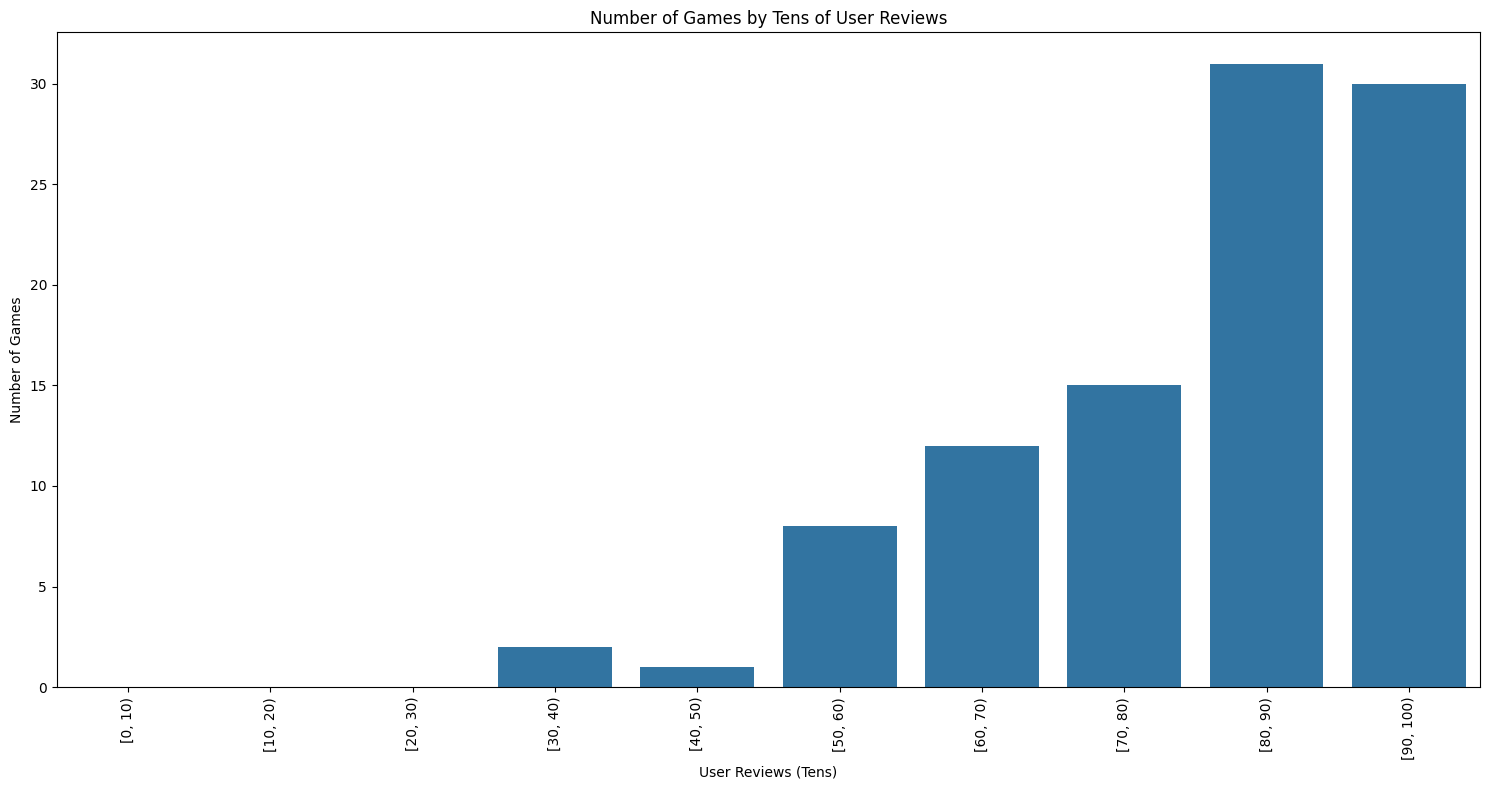

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bins = range(0, int(df_filled['user-reviews'].max()) + 10, 10)
df_filled['user_reviews_bin'] = pd.cut(df_filled['user-reviews'], bins=bins, right=False, include_lowest=True)

reviews_counts = df_filled['user_reviews_bin'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=reviews_counts.index.astype(str), y=reviews_counts.values)
plt.xticks(rotation=90)
plt.xlabel('User Reviews (Tens)')
plt.ylabel('Number of Games')
plt.title('Number of Games by Tens of User Reviews')
plt.tight_layout()
plt.show()

In [20]:
df_filled = df_filled.drop('user_reviews_bin', axis=1)

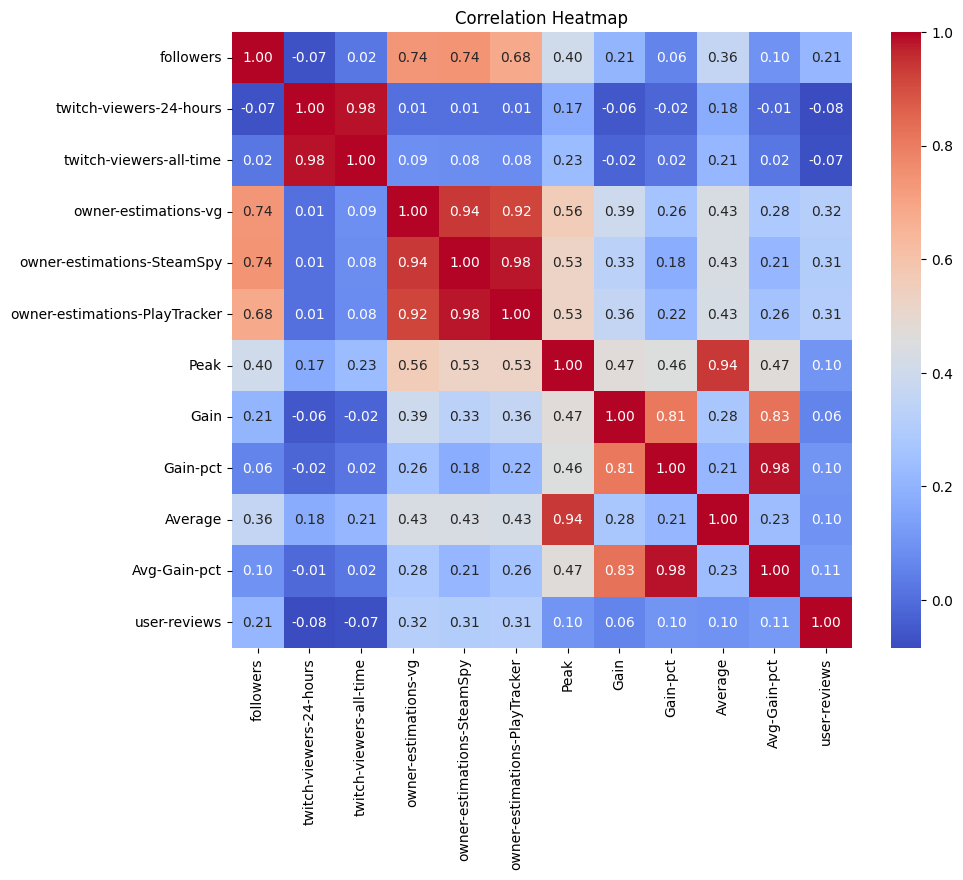

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_filled.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [22]:
correlation_matrix = df_filled.corr()

user_reviews_correlation = correlation_matrix['user-reviews'].drop('user-reviews')

high_inter_correlation_pairs = []
threshold_inter = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        if abs(correlation_matrix.iloc[i, j]) >= threshold_inter and col1 != 'user-reviews' and col2 != 'user-reviews':
            high_inter_correlation_pairs.append((col1, col2))

correlated_pairs_with_similar_user_reviews_corr = []
threshold_user_reviews_similarity = 0.01

for col1, col2 in high_inter_correlation_pairs:
    corr1_user_reviews = user_reviews_correlation.get(col1, 0)
    corr2_user_reviews = user_reviews_correlation.get(col2, 0)
    if abs(corr1_user_reviews - corr2_user_reviews) <= threshold_user_reviews_similarity:
        correlated_pairs_with_similar_user_reviews_corr.append((col1, col2))

highly_correlated_and_similarly_user_reviews_correlated_pairs = correlated_pairs_with_similar_user_reviews_corr

highly_correlated_and_similarly_user_reviews_correlated_pairs

[('owner-estimations-vg', 'owner-estimations-SteamSpy'),
 ('owner-estimations-vg', 'owner-estimations-PlayTracker'),
 ('owner-estimations-SteamSpy', 'owner-estimations-PlayTracker'),
 ('Peak', 'Average')]

In [23]:
df_important_features = df_filled.copy()

In [24]:
columns_to_merge_pairs = [
    ('twitch-viewers-24-hours', 'twitch-viewers-all-time'),
    ('Peak', 'Average'),
    ('Gain-pct', 'Avg-Gain-pct')
]

for col1, col2 in columns_to_merge_pairs:
    new_col_name = f'{col1}_{col2}_mean'
    df_important_features[new_col_name] = df_important_features[[col1, col2]].mean(axis=1)
    df_important_features = df_important_features.drop([col1, col2], axis=1)

columns_to_merge_trio = ['owner-estimations-vg', 'owner-estimations-SteamSpy', 'owner-estimations-PlayTracker']
new_col_name_trio = '_'.join(columns_to_merge_trio) + '_mean'
df_important_features[new_col_name_trio] = df_important_features[columns_to_merge_trio].mean(axis=1)
df_important_features = df_important_features.drop(columns_to_merge_trio, axis=1)

df_important_features.head()
df_important_features.columns

Index(['followers', 'Gain', 'user-reviews',
       'twitch-viewers-24-hours_twitch-viewers-all-time_mean',
       'Peak_Average_mean', 'Gain-pct_Avg-Gain-pct_mean',
       'owner-estimations-vg_owner-estimations-SteamSpy_owner-estimations-PlayTracker_mean'],
      dtype='object')

In [25]:
df_important_features.head()


,followers,Gain,user-reviews,twitch-viewers-24-hours_twitch-viewers-all-time_mean,Peak_Average_mean,Gain-pct_Avg-Gain-pct_mean,owner-estimations-vg_owner-estimations-SteamSpy_owner-estimations-PlayTracker_mean
0,55412.0,-5100.0,92.0,6889.5,10837.0,-29.5,7.401667e+05
1,34146.0,-173.0,96.0,13285.5,908.5,-13.5,1.319100e+06
2,48734.0,-458.0,89.0,38309.0,1240.0,-24.0,5.684333e+05
4,156996.0,305.0,91.0,27842.5,5886.0,-3.5,2.696667e+06
5,205951.0,-1252.0,87.0,100308.5,2547.0,-25.0,5.016667e+06


In [26]:
cols = df_important_features.columns.tolist()
user_reviews_index = cols.index('user-reviews')
cols.pop(user_reviews_index)
cols.append('user-reviews')
df_important_features = df_important_features[cols]
df_important_features.head()

,followers,Gain,twitch-viewers-24-hours_twitch-viewers-all-time_mean,Peak_Average_mean,Gain-pct_Avg-Gain-pct_mean,owner-estimations-vg_owner-estimations-SteamSpy_owner-estimations-PlayTracker_mean,user-reviews
0,55412.0,-5100.0,6889.5,10837.0,-29.5,7.401667e+05,92.0
1,34146.0,-173.0,13285.5,908.5,-13.5,1.319100e+06,96.0
2,48734.0,-458.0,38309.0,1240.0,-24.0,5.684333e+05,89.0
4,156996.0,305.0,27842.5,5886.0,-3.5,2.696667e+06,91.0
5,205951.0,-1252.0,100308.5,2547.0,-25.0,5.016667e+06,87.0


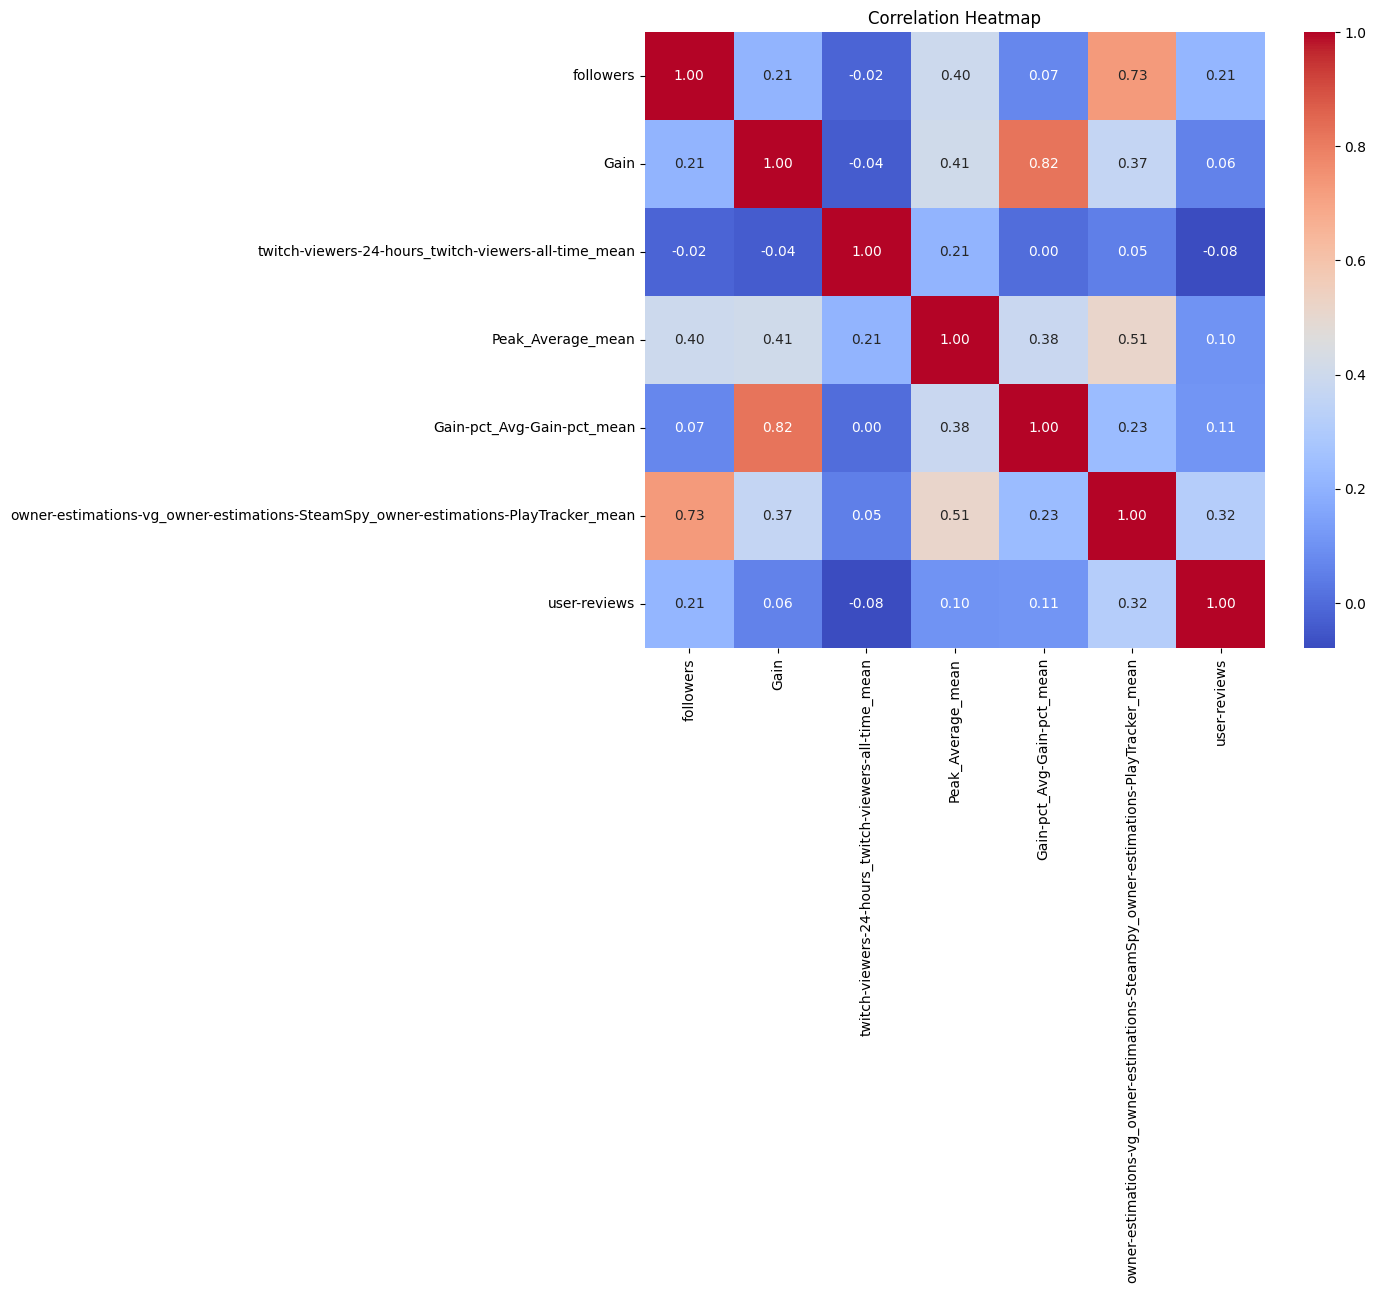

In [27]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_important_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

# Target and features (adjust 'posReviews' to your actual target column if needed)
target_col = 'user-reviews'
features = [col for col in df_important_features.columns if col != target_col and df_important_features[col].dtype in [np.int64, np.float64]]

results = []

n = int(len(df_important_features))
X = df_important_features[features].iloc[:n].fillna(0)
y = df_important_features[target_col].iloc[:n].fillna(0)
X_train, X_test, y_train, y_test = X, X, y, y  # Use all for both train/test for fair comparison
# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
results.append({'Model': 'LinearRegression', 'MAE': mae_lr, 'RMSE': rmse_lr})
# Random Forest
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
results.append({'Model': 'RandomForest', 'MAE': mae_rf, 'RMSE': rmse_rf})
# XGBoost (if available)
if xgb_available:
    xgb = XGBRegressor(random_state=42).fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
    results.append({'Model': 'XGBoost', 'MAE': mae_xgb, 'RMSE': rmse_xgb})

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE
0,LinearRegression,10.209282,12.767920
1,RandomForest,4.043232,4.994123
2,XGBoost,0.000640,0.000897


In [29]:
import joblib

# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [30]:
import joblib

# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [31]:
import joblib

# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [32]:
import joblib

# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [33]:
X_test.head()

,followers,Gain,twitch-viewers-24-hours_twitch-viewers-all-time_mean,Peak_Average_mean,Gain-pct_Avg-Gain-pct_mean,owner-estimations-vg_owner-estimations-SteamSpy_owner-estimations-PlayTracker_mean
0,55412.0,-5100.0,6889.5,10837.0,-29.5,7.401667e+05
1,34146.0,-173.0,13285.5,908.5,-13.5,1.319100e+06
2,48734.0,-458.0,38309.0,1240.0,-24.0,5.684333e+05
4,156996.0,305.0,27842.5,5886.0,-3.5,2.696667e+06
5,205951.0,-1252.0,100308.5,2547.0,-25.0,5.016667e+06


In [34]:
X_test.iloc[0]

,0
followers,55412.000000
Gain,-5100.000000
twitch-viewers-24-hours_twitch-viewers-all-time_mean,6889.500000
Peak_Average_mean,10837.000000
Gain-pct_Avg-Gain-pct_mean,-29.500000
owner-estimations-vg_owner-estimations-SteamSpy_owner-estimations-PlayTracker_mean,740166.666667


In [35]:
y_test.iloc[0]

np.float64(92.0)

In [36]:
# y_pred_xgb = xgb.predict(X_test.iloc[0])
# y_pred_xgb

In [37]:
import joblib

# Save the XGBoost model
joblib.dump(xgb, 'xgb_model.pkl')

['xgb_model.pkl']

In [38]:
import joblib

# Save the Linear Regression model
joblib.dump(lr, 'lr_model.pkl')

['lr_model.pkl']

In [40]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import re

# Function to parse numerical values from strings
def parse_number(s):
    if not isinstance(s, str):
        return None
    s = s.replace(',', '').replace(' ', '')
    match = re.findall(r'(-?[\d.]+)([kKmM]?)', s)
    if match:
        num, suffix = match[0]
        try:
            n = float(num)
            if suffix.lower() == 'k':
                n *= 1_000
            elif suffix.lower() == 'm':
                n *= 1_000_000
            return int(n)
        except:
            return None
    return None

# Load the models
models = {}
try:
    models['Linear Regression'] = joblib.load('lr_model.pkl')
    models['Random Forest'] = joblib.load('rf_model.pkl')
    models['XGBoost'] = joblib.load('xgb_model.pkl')
except FileNotFoundError:
    st.error("One or more model files (lr_model.pkl, rf_model.pkl, xgb_model.pkl) not found. Please ensure all models are trained and saved.")
    st.stop()

st.title('Game User Review Predictor')

st.write("This app predicts the 'user-reviews' score for a game based on its features.")

# Input features from the user
st.sidebar.header('Input Game Features')

def user_input_features():
    followers = st.sidebar.number_input('Followers', min_value=0.0, value=50000.0)
    gain = st.sidebar.number_input('Gain (Players)', value=-500.0)
    twitch_viewers_24_hours = st.sidebar.number_input('Twitch Viewers (24 hours)', min_value=0.0, value=1000.0)
    twitch_viewers_all_time = st.sidebar.number_input('Twitch Viewers (All time)', min_value=0.0, value=15000.0)
    peak = st.sidebar.number_input('Peak Players', min_value=0.0, value=15000.0)
    average = st.sidebar.number_input('Average Players', min_value=0.0, value=5000.0)
    gain_pct = st.sidebar.number_input('Gain Percentage', value=-20.0)
    avg_gain_pct = st.sidebar.number_input('Average Gain Percentage', value=-30.0)
    owner_estimations_vg = st.sidebar.number_input('Owner Estimations (VG)', min_value=0.0, value=700000.0)
    owner_estimations_steamspy = st.sidebar.number_input('Owner Estimations (SteamSpy)', min_value=0.0, value=750000.0)
    owner_estimations_playtracker = st.sidebar.number_input('Owner Estimations (PlayTracker)', min_value=0.0, value=1000000.0)

    data = {
        'followers': followers,
        'Gain': gain,
        'twitch-viewers-24-hours': twitch_viewers_24_hours,
        'twitch-viewers-all-time': twitch_viewers_all_time,
        'Peak': peak,
        'Average': average,
        'Gain-pct': gain_pct,
        'Avg-Gain-pct': avg_gain_pct,
        'owner-estimations-vg': owner_estimations_vg,
        'owner-estimations-SteamSpy': owner_estimations_steamspy,
        'owner-estimations-PlayTracker': owner_estimations_playtracker,
    }
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader('User Input Features')
st.write(input_df)

# Preprocessing and Feature Engineering for new input
def preprocess_input(input_df_raw):
    df_processed = input_df_raw.copy()

    columns_to_merge_pairs = [
        ('twitch-viewers-24-hours', 'twitch-viewers-all-time'),
        ('Peak', 'Average'),
        ('Gain-pct', 'Avg-Gain-pct')
    ]

    for col1, col2 in columns_to_merge_pairs:
        new_col_name = f'{col1}_{col2}_mean'
        df_processed[new_col_name] = df_processed[[col1, col2]].mean(axis=1)
        df_processed = df_processed.drop(columns=[col1, col2])

    columns_to_merge_trio = ['owner-estimations-vg', 'owner-estimations-SteamSpy', 'owner-estimations-PlayTracker']
    new_col_name_trio = '_'.join(columns_to_merge_trio) + '_mean'
    df_processed[new_col_name_trio] = df_processed[columns_to_merge_trio].mean(axis=1)
    df_processed = df_processed.drop(columns=columns_to_merge_trio)

    return df_processed

# Apply preprocessing to input data
processed_input = preprocess_input(input_df)

st.subheader('Processed Features for Prediction')
st.write(processed_input)

# Model selection
selected_model_name = st.sidebar.selectbox('Select Model for Prediction', list(models.keys()))
selected_model = models[selected_model_name]

# Make prediction
if st.button('Predict User Reviews'):
    prediction = selected_model.predict(processed_input)
    st.subheader(f'Predicted User Reviews Score using {selected_model_name}')
    st.write(f"{prediction[0]:.2f}")


Writing app.py


In [41]:
!pip install pyngrok

In [42]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.5 MB/s eta 0:00:00


In [43]:
from pyngrok import ngrok

# Set authentication token if you haven't already done so
ngrok.set_auth_token("36MakVKZgy5a81EnkMKpn9Z8jjO_4E6ERpLjj434PihiorrkG")

# Start Streamlit server on a specific port
!nohup streamlit run app.py --server.port 5011 &

# Start ngrok tunnel to expose the Streamlit server
ngrok_tunnel = ngrok.connect(addr='5011', proto='http', bind_tls=True)

# Print the URL of the ngrok tunnel
print(' * Tunnel URL:', ngrok_tunnel.public_url)

nohup: appending output to 'nohup.out'
 * Tunnel URL: https://de7a9dd89404.ngrok-free.app
